## Trabajo Practico python para ciencia de datos (Medidas, Estadisticas y Graficos)
## integrante: Santino Ferrazzuolo 

In [1]:
import pandas as pd
df = pd.read_csv("datos_tp.csv")
df

,Obs,Var_1,Var_2,Var_3,Var_4,Categoria
0,1,152,19,273,90,B
1,2,155,18,276,90,C
2,3,154,17,279,90,A
3,4,153,9,282,79,A
4,5,153,9,288,79,B
5,6,152,8,289,76,C
6,7,152,4,283,77,B
7,8,155,4,284,68,A
8,9,161,5,281,67,B
9,10,159,13,288,54,C


## punto 1A: Calcular Media, Mediana, Desvío, Coeficiente de variación y Cuartiles para cada una de 
## las variables.


In [2]:
variables = df[["Var_1","Var_2","Var_3","Var_4"]]

In [3]:
desvio = variables.std()
media = variables.mean()

In [4]:
cv = round(desvio/media * 100,2)

In [5]:
tabla = variables.describe()
tabla.loc["cv"] = cv


In [6]:
tabla = tabla.rename (index={"mean": "media", "std": "desvio", "25%": "Q1", "50%": "mediana", "75%": "Q3"})

In [7]:
tabla = tabla.drop(index=["count", "min", "max"])

In [8]:
tabla = tabla.round(2)
tabla

,Var_1,Var_2,Var_3,Var_4
media,158.75,9.50,288.44,65.25
desvio,6.57,4.90,9.47,18.40
Q1,153.00,6.00,281.75,49.50
mediana,157.00,8.00,288.00,67.50
Q3,163.25,12.25,294.75,79.00
cv,4.14,51.57,3.28,28.20


## Punto 1B: En cada caso, determinar qué medida de tendencia central representa mejor a la 
## variable (media o mediana) 

- Var_1 = media (cv 4,14%, datos muy parejos)
- Var_2 = mediana (cv 51,57%, datos muy dispersos)
- Var_3 = media (cv 3,28%, datos muy parejos)
- Var_4 = media (cv 28,20%, el CV supera levemente el 25%, media y mediana tienen valores cercanos)

## punto 1C: Calcular las medidas del punto a por categoría para la variable var_2.

In [9]:
datos_Var_2 = df.groupby("Categoria")["Var_2"]

In [10]:
desvio = datos_Var_2.std()
media = datos_Var_2.mean()

In [11]:
cv = round(desvio/media * 100,2)

In [12]:
tabla_var_2 = datos_Var_2.describe()
tabla_var_2["cv"] = cv

In [13]:
tabla_var_2 = tabla_var_2.rename(columns={"mean": "media", "std": "desvio", "25%": "Q1", "50%": "mediana", "75%": "Q3", "cv": "CV"})
tabla_var_2 = tabla_var_2.drop(columns=["count", "min", "max"])

In [14]:
tabla_var_2 = tabla_var_2.round(2)
tabla_var_2

,media,desvio,Q1,mediana,Q3,CV
Categoria,,,,,,
A,8.6,5.03,6.00,7.0,9.00,58.49
B,9.0,5.16,5.50,8.0,10.50,57.38
C,11.5,5.07,7.75,10.5,14.25,44.05


## punto 1D: Realizar un gráfico de torta para las categorías.

In [15]:
import matplotlib.pyplot as plt 

In [16]:
conteo = df["Categoria"].value_counts()
conteo

Categoria
B    7
A    5
C    4
Name: count, dtype: int64

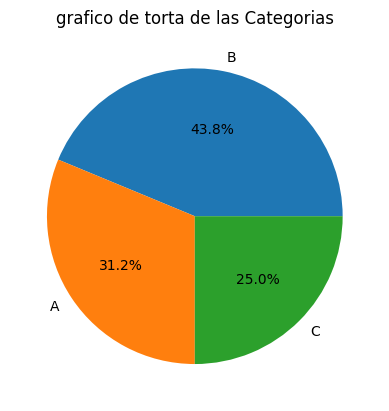

In [17]:
plt.pie(conteo.values, labels=conteo.index, autopct="%1.1f%%")
plt.title("grafico de torta de las Categorias")
plt.show()


## punto 1E:  Realizar un gráfico de dispersión para relaciones var_3 y var_4

In [18]:
import matplotlib.pyplot as plt 

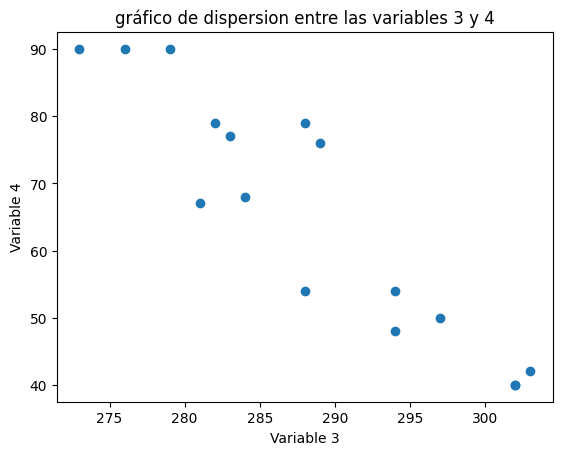

In [19]:
plt.scatter(df["Var_3"], df["Var_4"])
plt.title("gráfico de dispersion entre las variables 3 y 4")
plt.xlabel("Variable 3")
plt.ylabel("Variable 4")
plt.show()

## Se observa una relación negativa entre Var_3 y Var_4: a medida que Var_3 aumenta, Var_4 tiende a disminuir.

## punto 1F:  Realizar boxplot por categoría para la variable var_1.

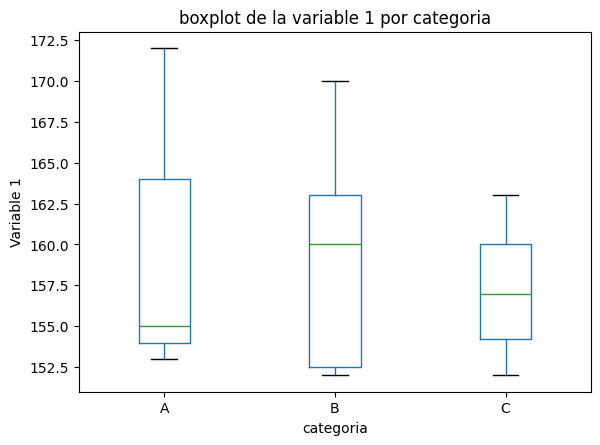

In [20]:
df.boxplot(column='Var_1', by='Categoria', grid=False)
plt.suptitle("")
plt.title("boxplot de la variable 1 por categoria")
plt.xlabel('categoria')
plt.ylabel('Variable 1')
plt.show()